#APLICACIÓN PRÁCTICA CON PYTHON

Configuración inicial

In [ ]:
# 📥 Instalación de librerías (ejecutar una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy import signal
from IPython.display import Audio, display
# ⚙️Configuración
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42) # Para reproducibilidad
print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## **Ejercicio 2.1: Generación y Análisis de Señales Sintéticas**
Generación de tres señales diferentes para estudiar los efectos del muestreo
y cuantización.

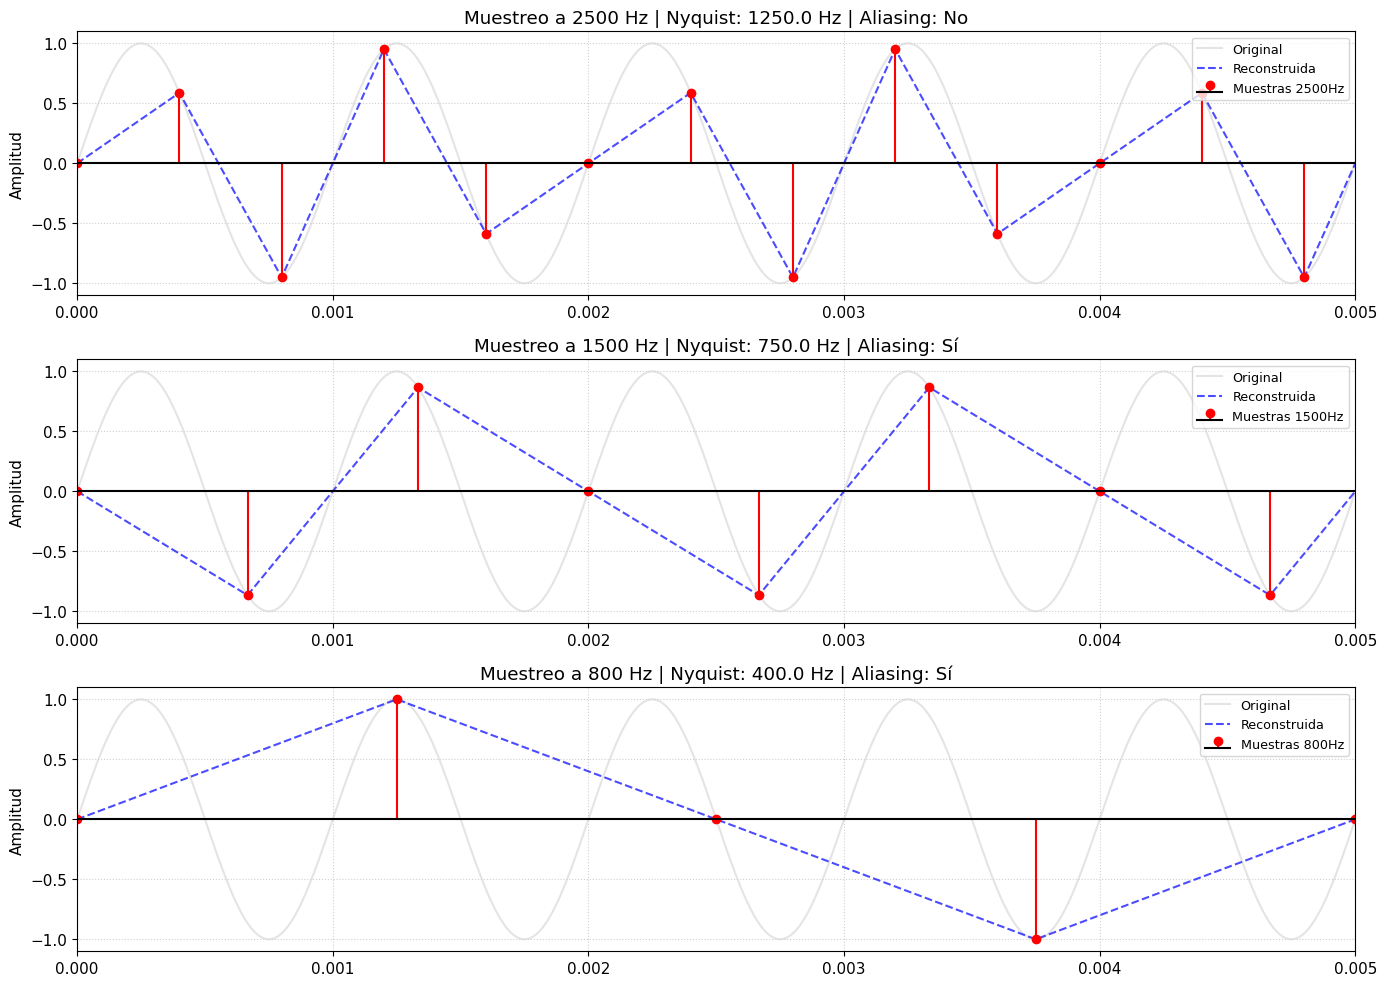

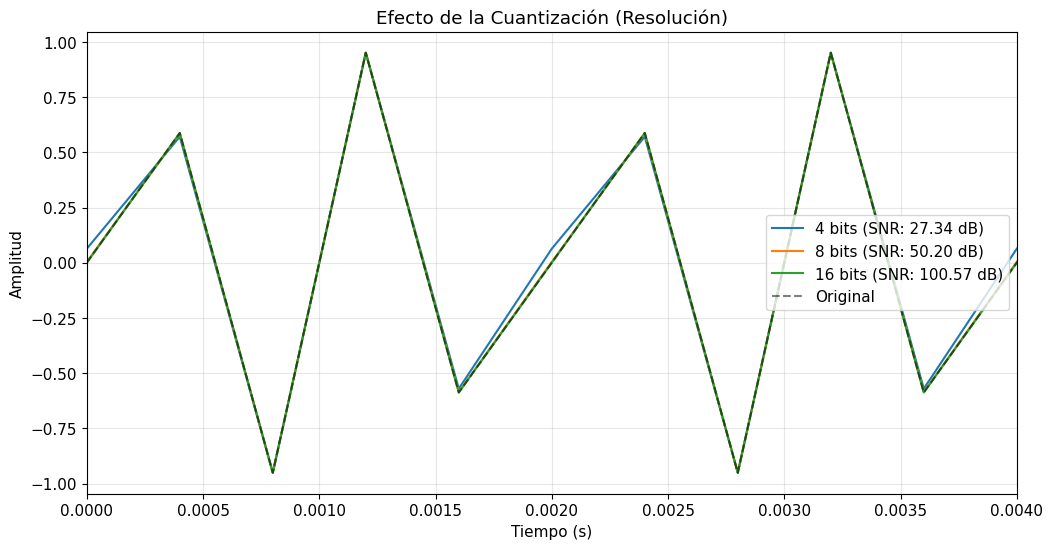


TABLA 1: ANÁLISIS DE MUESTREO
Tasa Muestreo (fs)   Nyquist Aliasing  Error RMS
           2500 Hz 1250.0 Hz       No     0.3538
           1500 Hz  750.0 Hz       Sí     0.7653
            800 Hz  400.0 Hz       Sí     0.8980

TABLA 2: ANÁLISIS DE CUANTIZACIÓN
 Bits  Niveles  SNR (dB)
    4       16     27.34
    8      256     50.20
   16    65536    100.57


In [ ]:
import pandas as pd

# Configuración inicial (estilo Colab del profe)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# =========================================================
# a) Generación de la señal "analógica" de referencia
# =========================================================
fs_ref = 100000
t_duracion = 0.1
f_senal = 1000  # 1000 Hz
A = 1.0

# Usamos linspace y endpoint=False como en el estándar de señales digitales
t_analog = np.linspace(0, t_duracion, int(fs_ref * t_duracion), endpoint=False)
x_analog = A * np.sin(2 * np.pi * f_senal * t_analog)

# =========================================================
# b) y c) Muestreo, Gráficos y Análisis de Nyquist/Aliasing
# =========================================================
fs_list = [2500, 1500, 800]
muestreo_results = []

plt.figure(figsize=(14, 10))

for i, fs in enumerate(fs_list):
    # Generar tiempos y señal muestreada
    num_muestras = int(fs * t_duracion)
    t_s = np.linspace(0, t_duracion, num_muestras, endpoint=False)
    x_s = A * np.sin(2 * np.pi * f_senal * t_s)

    # Reconstrucción (Unir los puntos para ver el efecto del aliasing)
    x_reconst = np.interp(t_analog, t_s, x_s)

    # Cálculos técnicos
    nyquist = fs / 2
    aliasing = "Sí" if fs < 2 * f_senal else "No"
    rms_error = np.sqrt(np.mean((x_analog - x_reconst)**2))

    # Guardar resultados
    muestreo_results.append({
        "Tasa Muestreo (fs)": f"{fs} Hz",
        "Nyquist": f"{nyquist} Hz",
        "Aliasing": aliasing,
        "Error RMS": round(rms_error, 4)
    })

    # Gráficos (mejorados con la línea de reconstrucción)
    plt.subplot(3, 1, i+1)
    plt.plot(t_analog, x_analog, color='lightgray', label="Original", alpha=0.6)
    plt.plot(t_analog, x_reconst, 'b--', alpha=0.7, label="Reconstruida")
    plt.stem(t_s, x_s, linefmt='red', markerfmt='ro', basefmt="black", label=f"Muestras {fs}Hz")

    plt.title(f"Muestreo a {fs} Hz | Nyquist: {nyquist} Hz | Aliasing: {aliasing}")
    plt.xlim(0, 0.005) # Zoom para ver ciclos
    plt.ylabel("Amplitud")
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================
# d) Cuantización (usando la señal fs1 = 2500 Hz)
# =========================================================
fs_q = 2500
t_q = np.linspace(0, t_duracion, int(fs_q * t_duracion), endpoint=False)
x_q_base = A * np.sin(2 * np.pi * f_senal * t_q)

bits_list = [4, 8, 16]
cuantizacion_results = []

plt.figure(figsize=(12, 6))

for bits in bits_list:
    levels = 2**bits

    # Proceso de cuantización técnica
    # 1. Normalizar al rango [0, 1]
    x_norm = (x_q_base - x_q_base.min()) / (x_q_base.max() - x_q_base.min())
    # 2. Cuantizar
    x_quant = np.round(x_norm * (levels - 1)) / (levels - 1)
    # 3. Volver al rango original
    x_final = x_quant * (x_q_base.max() - x_q_base.min()) + x_q_base.min()

    # Cálculo SNR
    ruido = x_q_base - x_final
    potencia_senal = np.mean(x_q_base**2)
    potencia_ruido = np.mean(ruido**2)
    # Evitar log de cero
    snr = 10 * np.log10(potencia_senal / potencia_ruido) if potencia_ruido > 0 else 100

    cuantizacion_results.append({
        "Bits": bits,
        "Niveles": levels,
        "SNR (dB)": round(snr, 2)
    })

    plt.plot(t_q, x_final, label=f"{bits} bits (SNR: {snr:.2f} dB)")

plt.plot(t_q, x_q_base, 'k--', label="Original", alpha=0.5)
plt.title("Efecto de la Cuantización (Resolución)")
plt.xlim(0, 0.004)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# ENTREGABLES (Tablas de resultados)
# =========================================================
print("\n" + "="*40)
print("TABLA 1: ANÁLISIS DE MUESTREO")
print("="*40)
df_muestreo = pd.DataFrame(muestreo_results)
print(df_muestreo.to_string(index=False))

print("\n" + "="*40)
print("TABLA 2: ANÁLISIS DE CUANTIZACIÓN")
print("="*40)
df_cuant = pd.DataFrame(cuantizacion_results)
print(df_cuant.to_string(index=False))

### **Análisis de señales sintéticas: efectos del muestreo y la cuantización**

Se observó que al disminuir la frecuencia de muestreo por debajo del criterio de Nyquist (fs < 2f), aparece el fenómeno de aliasing, donde la señal reconstruida no representa correctamente la señal original, generando una frecuencia aparente incorrecta.
Esto se evidencia claramente en los casos de 1500 Hz y 800 Hz, donde además el error RMS aumenta significativamente (0.7653 y 0.8980 respectivamente), indicando una mayor distorsión.

En cambio, para una frecuencia de muestreo de 2500 Hz, que cumple el criterio de Nyquist, no se observa aliasing y el error RMS es considerablemente menor (0.3538), logrando una mejor aproximación de la señal original.

Respecto a la cuantización, se verificó que al aumentar la cantidad de bits se incrementa la resolución de la señal, reduciendo el error de cuantización. Esto se refleja en el aumento del SNR, pasando de 27.34 dB (4 bits) a 100.57 dB (16 bits), lo que indica una mejora significativa en la calidad de la señal digital.

En conclusión, tanto una frecuencia de muestreo adecuada como una mayor cantidad de bits en la cuantización son fundamentales para preservar la fidelidad de la señal en sistemas digitales.

# **Ejercicio 2.2: Creación de Dataset Sintético**

Creación un dataset simulado de comandos de voz con características controladas.

Dataset generado: 40 muestras
      duracion        amplitud_max       
          mean    std         mean    std
clase                                    
agudo    2.072  0.294        0.870  0.236
grave    2.133  0.277        1.113  0.161
medio    2.130  0.342        1.053  0.295
ruido    1.906  0.262        0.768  0.119


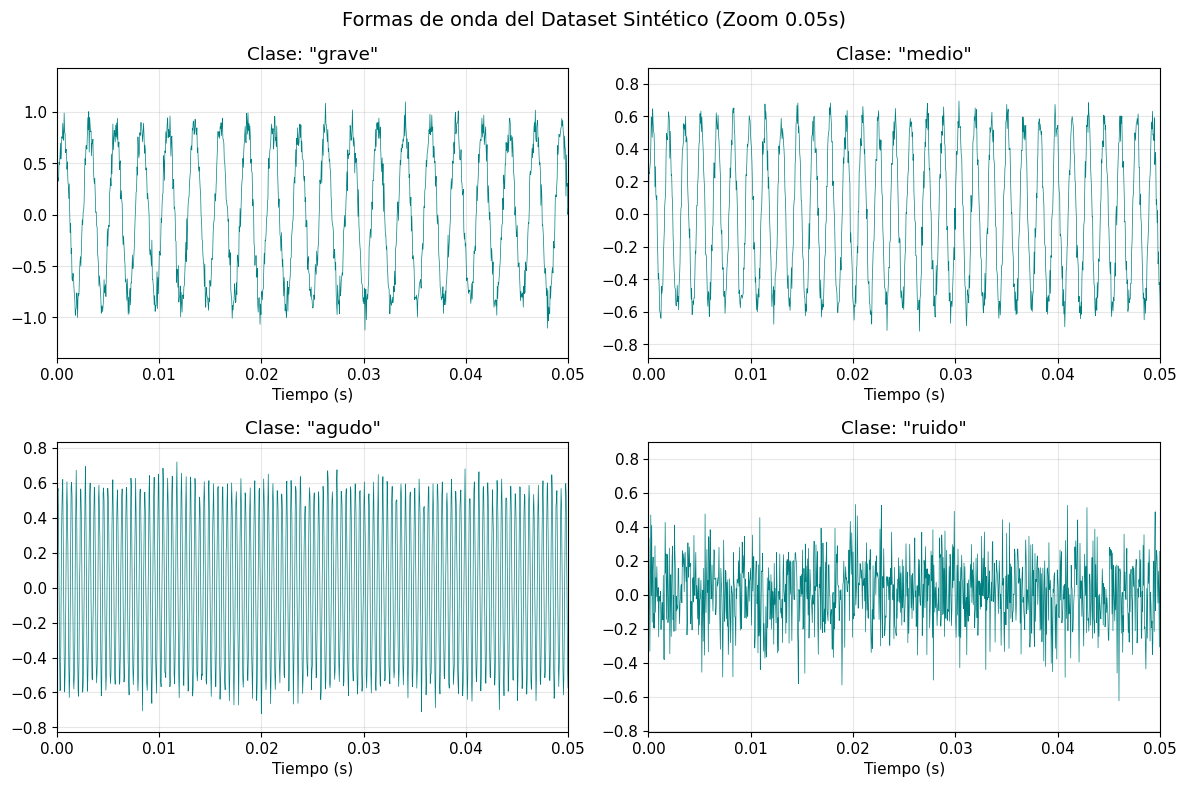

In [ ]:
# Configuración base
sr = 22050
clases = ["grave", "medio", "agudo", "ruido"]
muestras_por_clase = 10
dataset = []
np.random.seed(42)

# Rangos de frecuencia pedidos por el profe
frecuencias_clases = {
    "grave": (200, 400),
    "medio": (600, 1000),
    "agudo": (1500, 2500)
}

for etiqueta in clases:
    for i in range(muestras_por_clase):
        # 1. Duración variable (1.5 a 2.5 seg)
        duracion = np.random.uniform(1.5, 2.5)
        t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)

        # 2. Generación del audio según la clase
        if etiqueta == "ruido":
            # Ruido blanco puro
            audio_base = np.random.normal(0, 1, len(t))
        else:
            # Senoide con frecuencia aleatoria dentro del rango de la clase
            f_min, f_max = frecuencias_clases[etiqueta]
            f_random = np.random.uniform(f_min, f_max)
            audio_base = np.sin(2 * np.pi * f_random * t)

        # 3. Amplitud variable (0.5 a 1.0)
        amplitud = np.random.uniform(0.5, 1.0)
        audio_base = audio_base * (amplitud / np.max(np.abs(audio_base)))

        # 4. Agregar Ruido de fondo (SNR entre 10-20 dB)
        snr_db = np.random.uniform(10, 20)
        potencia_audio = np.mean(audio_base**2)
        potencia_ruido = potencia_audio / (10**(snr_db / 10))
        ruido_fondo = np.sqrt(potencia_ruido) * np.random.normal(0, 1, len(audio_base))

        audio_final = audio_base + ruido_fondo

        # 5. Guardar en lista de diccionarios
        dataset.append({
            'audio': audio_final.astype(np.float32),
            'sr': sr,
            'clase': etiqueta,
            'duracion': round(duracion, 3),
            'amplitud_max': round(float(np.max(np.abs(audio_final))), 3)
        })

# Crear DataFrame para el análisis
df_dataset = pd.DataFrame(dataset)

print(f"Dataset generado: {len(df_dataset)} muestras")
# Mostrar resumen por clase (como hizo tu compañero)
print(df_dataset.groupby("clase")[["duracion", "amplitud_max"]].agg(["mean", "std"]).round(3))

# --- Visualización: Un ejemplo por clase ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, etiqueta in enumerate(clases):
    # Tomamos la primera muestra de cada clase
    ejemplo = df_dataset[df_dataset['clase'] == etiqueta].iloc[0]
    audio = ejemplo['audio']
    t_ej = np.linspace(0, ejemplo['duracion'], len(audio))

    axes[idx].plot(t_ej, audio, linewidth=0.5, color='teal')
    axes[idx].set_title(f'Clase: "{etiqueta}"')
    axes[idx].set_xlim(0, 0.05) # Hacemos zoom al inicio para ver la onda
    axes[idx].set_xlabel("Tiempo (s)")
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Formas de onda del Dataset Sintético (Zoom 0.05s)", fontsize=14)
plt.tight_layout()
plt.show()

## **Análisis del dataset sintético**
En este ejercicio se generó un dataset sintético compuesto por 40 muestras de audio, distribuidas en cuatro clases: grave, medio, agudo y ruido. Cada clase fue diseñada con características específicas de frecuencia para simular distintos tipos de señales, lo que permite analizarlas posteriormente de manera controlada.

Se incorporó variabilidad en los datos para hacer el dataset más realista, incluyendo:

Duraciones aleatorias entre 1.5 y 2.5 segundos
Amplitudes variables
Ruido de fondo con diferentes niveles de SNR

Esto es importante porque en situaciones reales (como grabaciones de voz) los datos nunca son perfectamente uniformes.

A partir del resumen estadístico, se puede observar que:

Las duraciones promedio de las señales son similares entre clases, aunque con cierta variabilidad, lo que simula condiciones reales de grabación.
Las amplitudes máximas presentan diferencias, especialmente en la clase ruido, que tiende a tener valores más bajos y menos consistentes.
Las clases grave, medio y agudo mantienen una estructura más estable, ya que están basadas en señales senoidales controladas.

En las visualizaciones de las formas de onda se pueden notar diferencias claras:

-Las señales graves tienen menos oscilaciones (frecuencia baja)
-Las agudas presentan muchas más oscilaciones en el mismo intervalo de tiempo
-El ruido no tiene un patrón definido, lo que lo hace más irregular.

# **Ejercicio 2.3: Preparación de datos crudos**

Pipeline completo de preprocessing del dataset generado.

,Clase,Duración Original,Duración Final,Amp Máx Original,Amp Máx Final,Porc Reducción Trimming
0,grave,1.875,2.0,1.301,1.0,0.0
1,grave,2.291,2.0,1.244,1.0,0.0
2,grave,2.157,2.0,1.121,1.0,0.0
3,grave,2.093,2.0,1.018,1.0,0.0
4,grave,1.895,2.0,1.311,1.0,0.0


/tmp/ipykernel_2344/794657821.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_metadatos['Amp Máx Original'], df_metadatos['Amp Máx Final']], labels=['Original', 'Normalizada'])


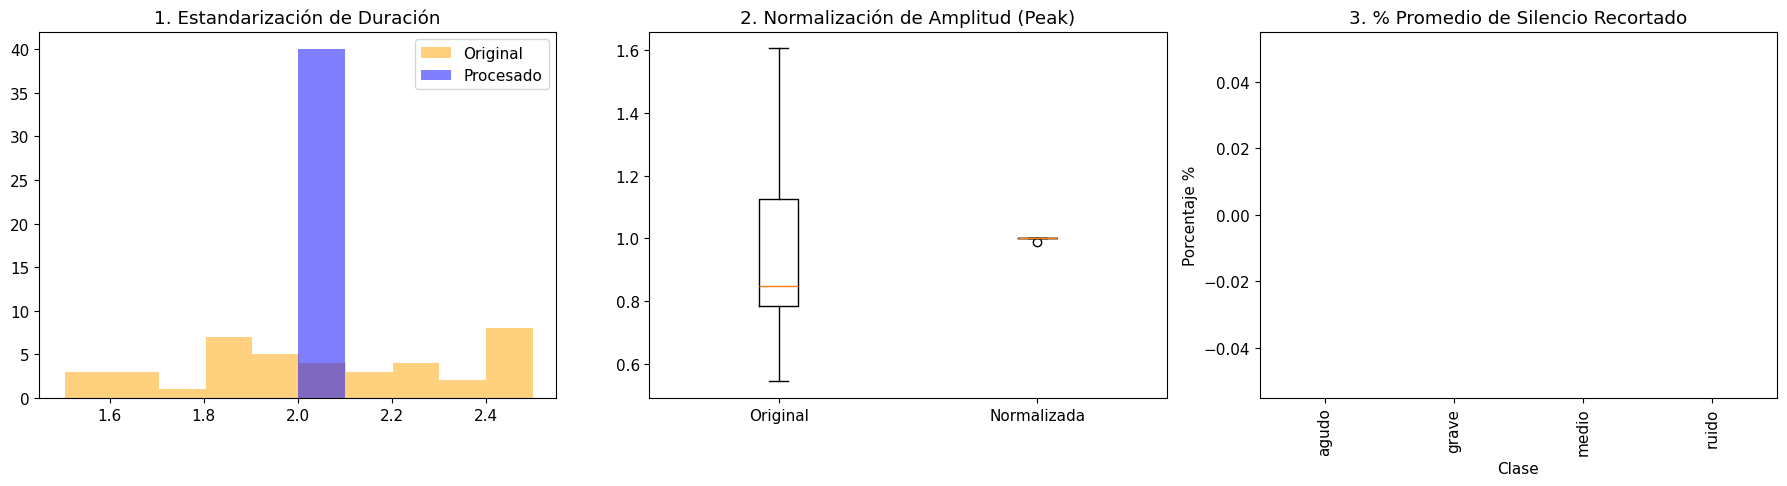

In [ ]:

# =========================================================
# 1. ENTREGABLE: Función preparar_audio() implementada
# =========================================================
def preparar_audio(audio, sr, duracion_objetivo=2.0, top_db=30):
    """
    Pipeline completo de preparación:
    1. Mono, 2. Trimming, 3. Normalización, 4. Resampling, 5. Pad/Crop
    """
    # 1. Convertir a mono si es necesario
    if len(audio.shape) > 1:
        audio = librosa.to_mono(audio)

    # 2. Recortar silencios (trimming)
    largo_antes_trim = len(audio)
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)
    muestras_recortadas = largo_antes_trim - len(audio_trim)

    # 3. Normalizar amplitud (peak normalization)
    if np.max(np.abs(audio_trim)) > 0:
        audio_norm = librosa.util.normalize(audio_trim)
    else:
        audio_norm = audio_trim

    # 4. Remuestrear a 22050 Hz si es necesario
    target_sr = 22050
    if sr != target_sr:
        audio_resampled = librosa.resample(audio_norm, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    else:
        audio_resampled = audio_norm

    # 5. Ajustar duración (pad o crop)
    num_muestras_objetivo = int(duracion_objetivo * sr)
    if len(audio_resampled) < num_muestras_objetivo:
        # Padding
        audio_procesado = np.pad(audio_resampled, (0, num_muestras_objetivo - len(audio_resampled)))
    else:
        # Crop centrado
        inicio = (len(audio_resampled) - num_muestras_objetivo) // 2
        audio_procesado = audio_resampled[inicio : inicio + num_muestras_objetivo]

    metadatos = {
        'muestras_recortadas': muestras_recortadas,
        'porc_silencio_recortado': (muestras_recortadas / largo_antes_trim) * 100,
        'amp_max': np.max(np.abs(audio_procesado))
    }

    return audio_procesado, sr, metadatos

# --- Procesamiento del Dataset ---
dataset_procesado = []
metadatos_lista = []

for i, muestra in enumerate(dataset):
    audio_p, sr_p, meta = preparar_audio(muestra['audio'], muestra['sr'])

    metadatos_lista.append({
        'Clase': muestra['clase'],
        'Duración Original': muestra['duracion'],
        'Duración Final': len(audio_p) / sr_p,
        'Amp Máx Original': muestra['amplitud_max'],
        'Amp Máx Final': meta['amp_max'],
        'Porc Reducción Trimming': meta['porc_silencio_recortado']
    })

    dataset_procesado.append({'audio': audio_p, 'sr': sr_p, 'clase': muestra['clase']})

# =========================================================
# 2. ENTREGABLE: DataFrame con metadatos comparativos
# =========================================================
df_metadatos = pd.DataFrame(metadatos_lista)
display(df_metadatos.head()) # Muestra las primeras filas

# =========================================================
# 3. ENTREGABLE: 3 gráficos de visualización
# =========================================================
plt.figure(figsize=(18, 5))

# Gráfico 1: Histograma de duraciones
plt.subplot(1, 3, 1)
plt.hist(df_metadatos['Duración Original'], alpha=0.5, label='Original', color='orange')
plt.hist(df_metadatos['Duración Final'], alpha=0.5, label='Procesado', color='blue')
plt.title("1. Estandarización de Duración")
plt.legend()

# Gráfico 2: Boxplot de Amplitudes
plt.subplot(1, 3, 2)
plt.boxplot([df_metadatos['Amp Máx Original'], df_metadatos['Amp Máx Final']], labels=['Original', 'Normalizada'])
plt.title("2. Normalización de Amplitud (Peak)")

# Gráfico 3: Porcentaje de Trimming por clase
plt.subplot(1, 3, 3)
df_metadatos.groupby('Clase')['Porc Reducción Trimming'].mean().plot(kind='bar', color='teal')
plt.title("3. % Promedio de Silencio Recortado")
plt.ylabel("Porcentaje %")

plt.tight_layout()
plt.show()


## **Análisis del resultado preprocesamiento de dataset**

El pipeline de procesamiento permitió homogeneizar la duración de todas las señales a 2.0 segundos, eliminando la variabilidad temporal inicial.
Asimismo, la normalización de amplitud unificó los valores máximos a 1.0, reduciendo diferencias de escala entre muestras.

En cuanto al trimming, no se observó una reducción significativa en las señales analizadas, lo que sugiere que el dataset original presentaba escaso contenido de silencio en los extremos.

Finalmente, el remuestreo a 22050 Hz y la estandarización del formato permiten obtener un dataset consistente, adecuado para etapas posteriores de análisis o entrenamiento de modelos.

## **Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros**

Análisis el contenido frecuencial de cada clase del dataset.

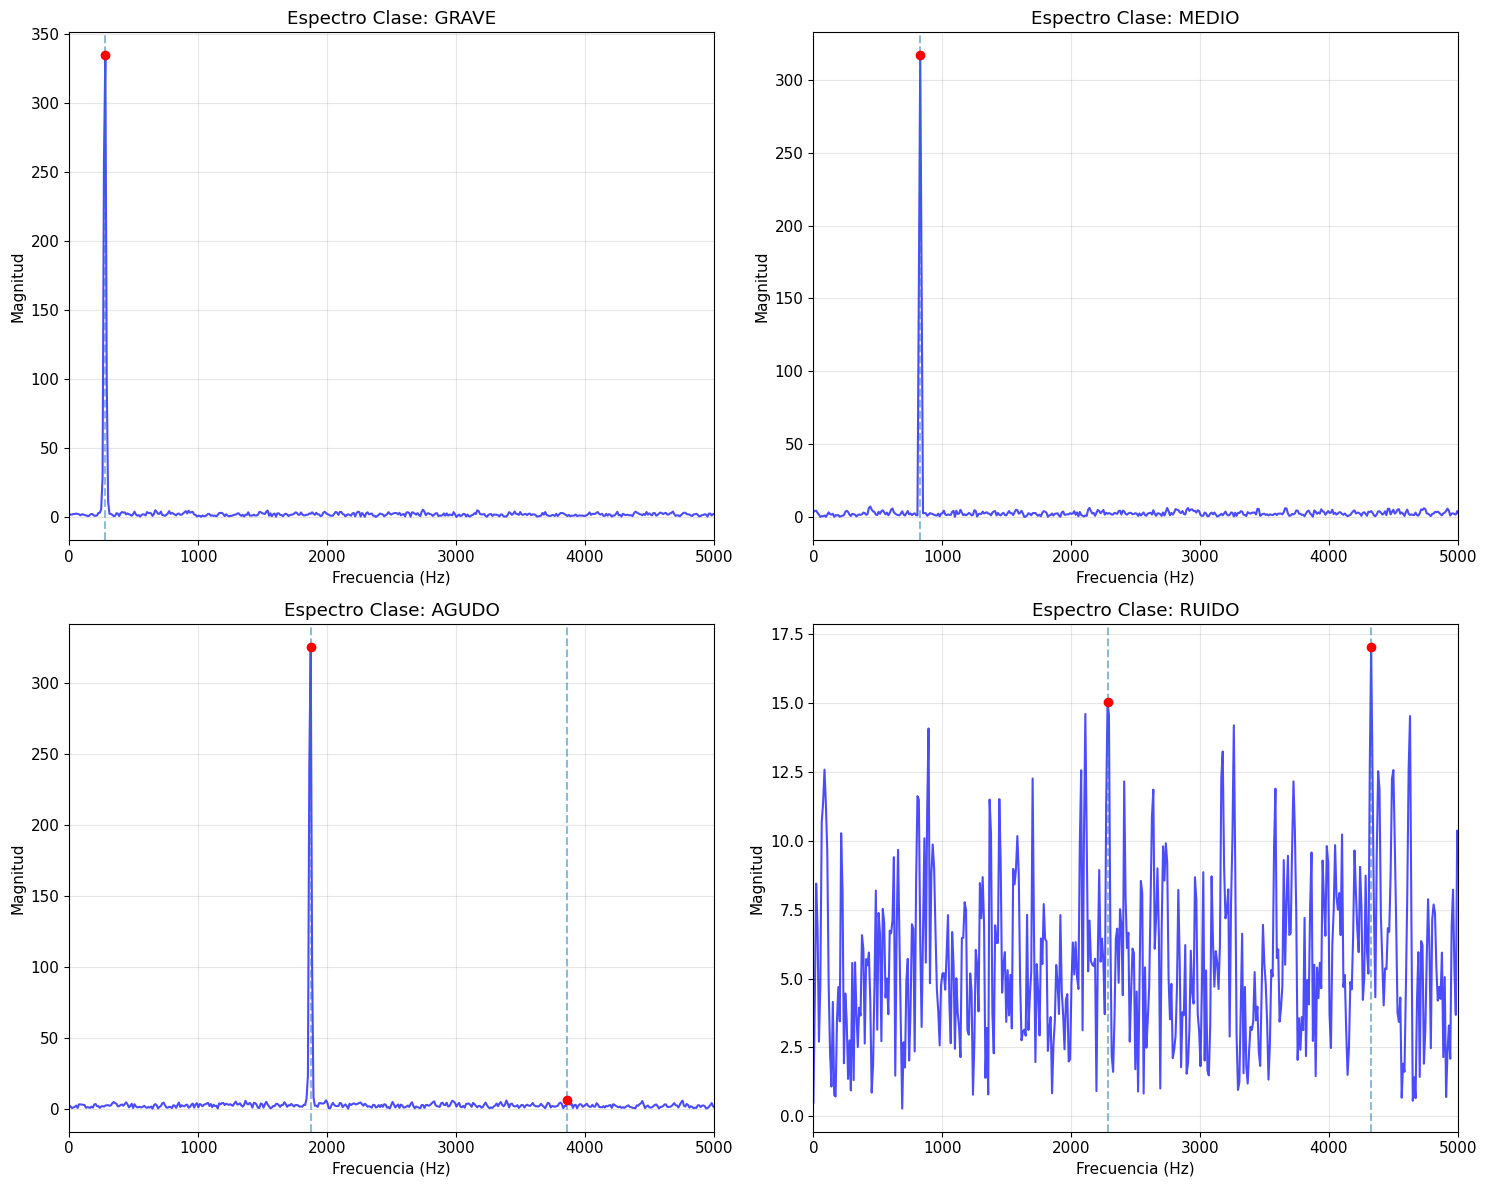

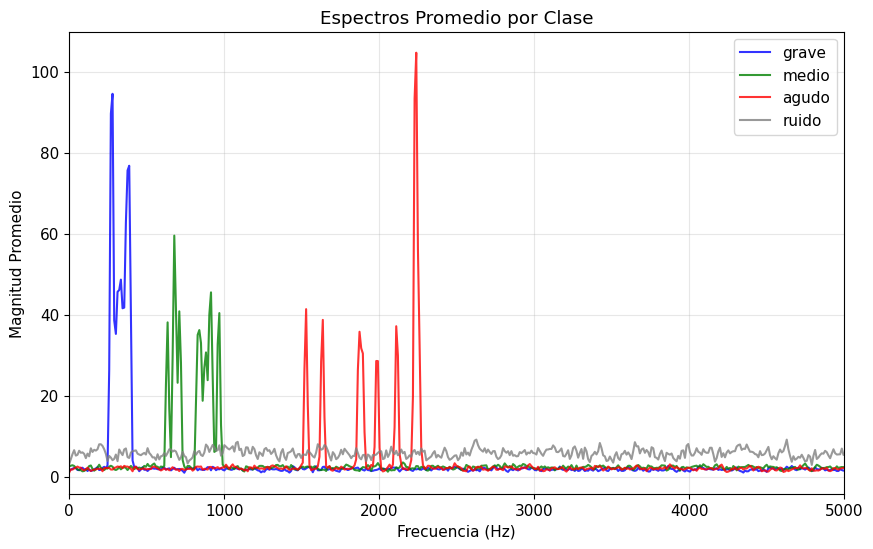


--- TABLA DE CARACTERÍSTICAS FRECUENCIALES ---


,Clase,F0 (Hz),Pico Máx (Hz),BW -20dB (Hz)
0,grave,53.83,279.93,21.53
1,medio,21.53,829.03,21.53
2,agudo,75.37,1873.39,21.53
3,ruido,86.13,4328.17,11014.23


In [ ]:
# =========================================================
# a) Selección de ejemplos representativos (RMS medio)
# =========================================================
ejemplos_representativos = []

for etiqueta in df_dataset['clase'].unique():
    muestras_clase = [m for m in dataset_procesado if m['clase'] == etiqueta]

    rms_values = [np.sqrt(np.mean(m['audio']**2)) for m in muestras_clase]
    rms_medio = np.mean(rms_values)

    idx_rep = np.argmin(np.abs(rms_values - rms_medio))
    ejemplos_representativos.append(muestras_clase[idx_rep])

# =========================================================
# b) FFT + análisis de picos
# =========================================================
n_fft = 2048
sr = 22050
frecuencias = np.fft.rfftfreq(n_fft, d=1/sr)

stats_frecuencias = []

plt.figure(figsize=(15, 12))

for i, ejemplo in enumerate(ejemplos_representativos):

    # Aplicar ventana (IMPORTANTE)
    ventana = np.hanning(n_fft)
    audio = ejemplo['audio'][:n_fft] * ventana

    # FFT
    fft_mag = np.abs(np.fft.rfft(audio, n=n_fft))
    fft_db = librosa.amplitude_to_db(fft_mag, ref=np.max)

    # Detección de picos
    picos_idx = librosa.util.peak_pick(
        fft_mag, pre_max=10, post_max=10,
        pre_avg=10, post_avg=10,
        delta=0.1, wait=10
    )

    picos_f = frecuencias[picos_idx]
    picos_m = fft_mag[picos_idx]

    # Top 3 picos más importantes
    if len(picos_m) >= 3:
        idx_top3 = np.argsort(picos_m)[-3:][::-1]
        top3_f = picos_f[idx_top3]
    else:
        top3_f = picos_f

    # -----------------------------
    # Frecuencia fundamental (mejor criterio)
    # -----------------------------
    picos_validos = picos_f[picos_f > 20]
    f0 = np.min(picos_validos) if len(picos_validos) > 0 else 0

    # -----------------------------
    # Pico máximo
    # -----------------------------
    idx_peak = np.argmax(fft_mag)
    f_max = frecuencias[idx_peak]

    # -----------------------------
    # Ancho de banda a -20 dB
    # -----------------------------
    peak_db = fft_db[idx_peak]
    indices_validos = np.where(fft_db >= peak_db - 20)[0]

    if len(indices_validos) > 0:
        bw_20db = frecuencias[indices_validos[-1]] - frecuencias[indices_validos[0]]
    else:
        bw_20db = 0

    # Guardar resultados
    stats_frecuencias.append({
        'Clase': ejemplo['clase'],
        'F0 (Hz)': round(f0, 2),
        'Pico Máx (Hz)': round(f_max, 2),
        'BW -20dB (Hz)': round(bw_20db, 2)
    })

    # -----------------------------
    # Gráfico
    # -----------------------------
    plt.subplot(2, 2, i+1)
    plt.plot(frecuencias, fft_mag, color='blue', alpha=0.7)

    # marcar picos
    plt.scatter(top3_f, fft_mag[np.searchsorted(frecuencias, top3_f)],
                color='red', zorder=5)

    for f_peak in top3_f:
        plt.axvline(f_peak, linestyle='--', alpha=0.5)

    plt.title(f"Espectro Clase: {ejemplo['clase'].upper()}")
    plt.xlim(0, 5000)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# c) Espectros promedio por clase
# =========================================================
plt.figure(figsize=(10, 6))

colores = {
    'grave': 'blue',
    'medio': 'green',
    'agudo': 'red',
    'ruido': 'gray'
}

for etiqueta in colores.keys():
    muestras = [m['audio'][:n_fft] for m in dataset_procesado if m['clase'] == etiqueta]

    espectros = []
    for m in muestras:
        ventana = np.hanning(n_fft)
        fft_mag = np.abs(np.fft.rfft(m * ventana, n=n_fft))
        espectros.append(fft_mag)

    espectro_promedio = np.mean(espectros, axis=0)

    plt.plot(frecuencias, espectro_promedio,
             label=etiqueta, color=colores[etiqueta], alpha=0.8)

plt.title("Espectros Promedio por Clase")
plt.xlim(0, 5000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud Promedio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# d) Tabla final
# =========================================================
df_stats = pd.DataFrame(stats_frecuencias)

print("\n--- TABLA DE CARACTERÍSTICAS FRECUENCIALES ---")
display(df_stats)

## **Análisis y respuestas – FFT y espectros**

**¿Se pueden distinguir las clases solo mirando el espectro?**

Sí, las clases pueden distinguirse a partir del análisis espectral. Las señales presentan distribuciones de energía características en diferentes rangos de frecuencia. En particular, las clases “grave”, “medio” y “agudo” muestran picos dominantes en distintas zonas del espectro, mientras que la clase “ruido” presenta un comportamiento más uniforme, sin picos claramente definidos.

**¿Qué rangos de frecuencia son más discriminativos?**

Los rangos de frecuencia más relevantes para la discriminación son:

Bajas frecuencias (≈ 0–500 Hz): predominantes en señales “grave”

*   Bajas frecuencias (≈ 0–500 Hz): predominantes en señales “grave”
*   Frecuencias medias (≈ 500–2000 Hz): características de señales “medio”
*   Altas frecuencias (> 2000 Hz): dominantes en señales “agudo”


Estos rangos permiten diferenciar las clases según la ubicación de sus picos principales y la distribución de energía en el espectro.

**¿Hay solapamiento entre clases?**

Sí, existe cierto solapamiento espectral entre algunas clases, especialmente entre “medio” y “agudo”, ya que comparten componentes en rangos intermedios de frecuencia. Sin embargo, las diferencias en la concentración de energía y en la ubicación de los picos principales permiten su discriminación. La clase “ruido”, por su parte, se distingue claramente debido a su espectro amplio y sin estructura definida.

**Conclusión sobre discriminabilidad**

El análisis mediante FFT permitió evidenciar diferencias claras en el contenido frecuencial de cada clase. Las señales presentan patrones espectrales distintivos que facilitan su clasificación, especialmente a partir de la frecuencia fundamental, el pico máximo y el ancho de banda.

Las clases tonalmente definidas (grave, medio, agudo) muestran concentraciones de energía en rangos específicos, mientras que la clase “ruido” presenta un espectro más disperso.

En conjunto, estos resultados demuestran que el dominio frecuencial es altamente informativo y adecuado para la discriminación de señales de audio.

## **Ejercicio 2.5: Extracción de Features y EDA Estadístico**

Extracción de features y análisis estadístico del dataset.


--- DATAFRAME DE FEATURES ---


,clase,duracion,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness
0,grave,2.0,0.460911,0.046527,3893.507226,3378.431326,8332.483331,0.060198
1,grave,2.0,0.539010,0.038614,3792.070479,3558.423960,8515.886820,0.008803
2,grave,2.0,0.502397,0.046151,4090.879649,3566.856781,8735.055226,0.015763
3,grave,2.0,0.483474,0.047268,4039.818062,3538.797627,8690.380018,0.012603
4,grave,2.0,0.449723,0.060384,4256.914919,3406.089343,8628.007981,0.060960



--- RESUMEN ESTADÍSTICO POR CLASE ---


duracion                   rms                         zcr         ...  \
          mean  std  min  max   mean    std    min    max   mean    std  ...   
clase                                                                    ...   
agudo      2.0  0.0  2.0  2.0  0.491  0.056  0.403  0.556  0.171  0.025  ...   
grave      2.0  0.0  2.0  2.0  0.504  0.044  0.450  0.567  0.043  0.008  ...   
medio      2.0  0.0  2.0  2.0  0.464  0.057  0.400  0.558  0.078  0.012  ...   
ruido      2.0  0.0  2.0  2.0  0.229  0.015  0.205  0.250  0.453  0.043  ...   

      spectral_bandwidth           spectral_rolloff                     \
                     min       max             mean      std       min   
clase                                                                    
agudo           2615.152  3186.489         8446.547  438.549  7456.676   
grave           2919.318  3586.663         8440.434  488.172  7102.121   
medio           2810.299  3470.682         8484.565  551.410  7187.263   
ruido           2458.721  3192.179         8733.088  776.734  7232.062   

                spectral_flatness                       
            max              mean    std    min    max  
clase                                                   
agudo  8934.299             0.049  0.058  0.007  0.189  
grave  8741.367             0.039  0.059  0.006  0.195  
medio  8970.807             0.059  0.063  0.009  0.204  
ruido  9391.942             0.591  0.037  0.557  0.663  

[4 rows x 28 columns]

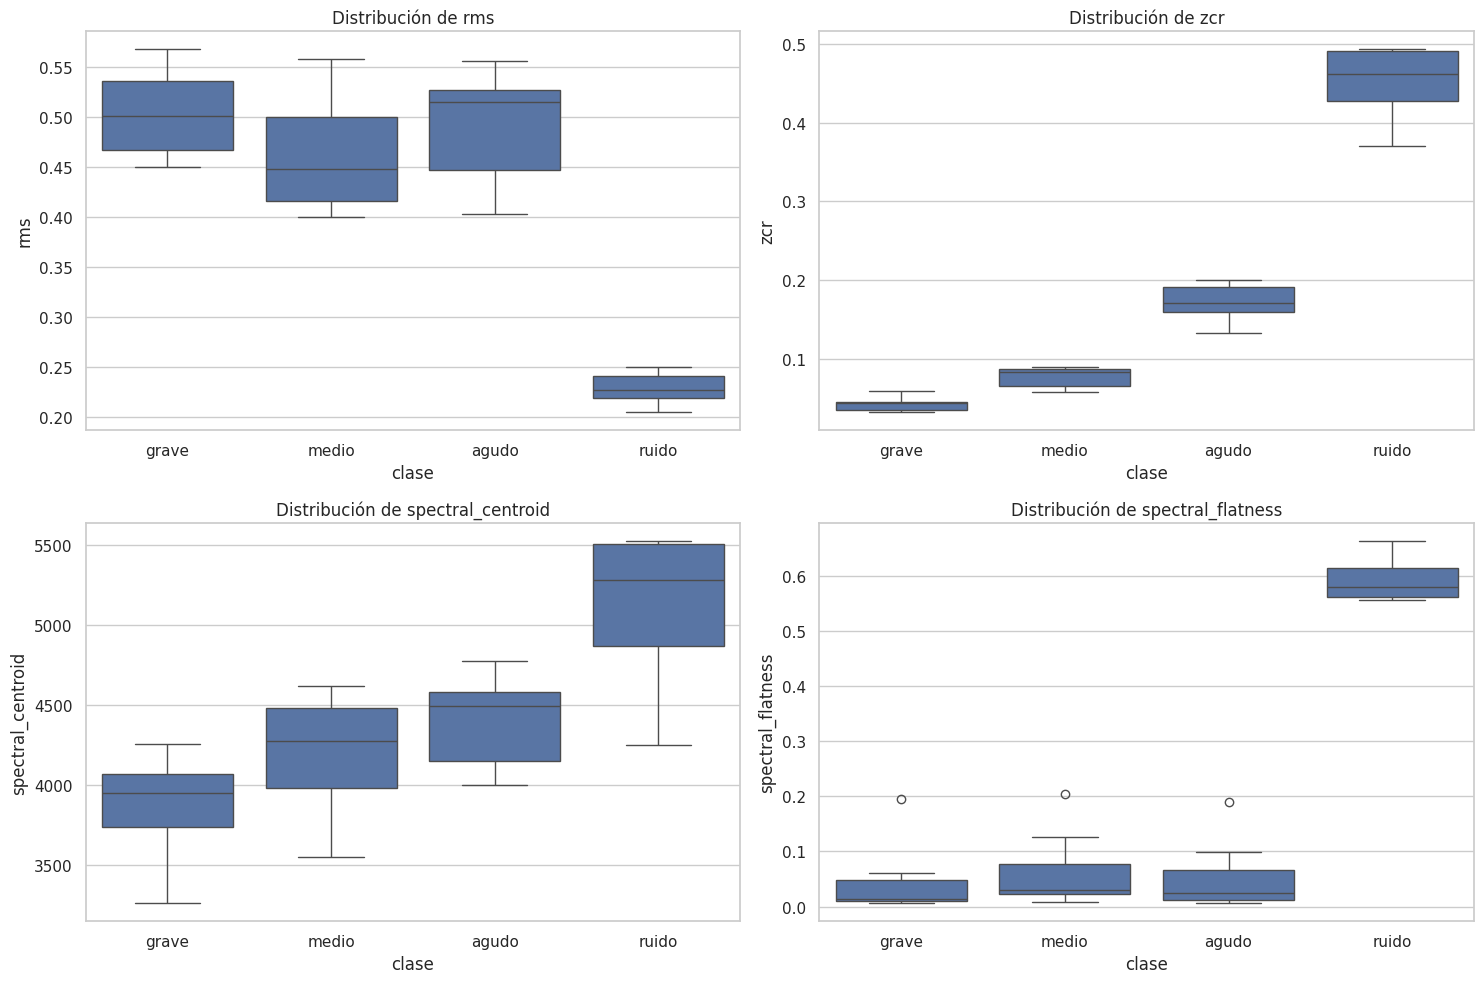

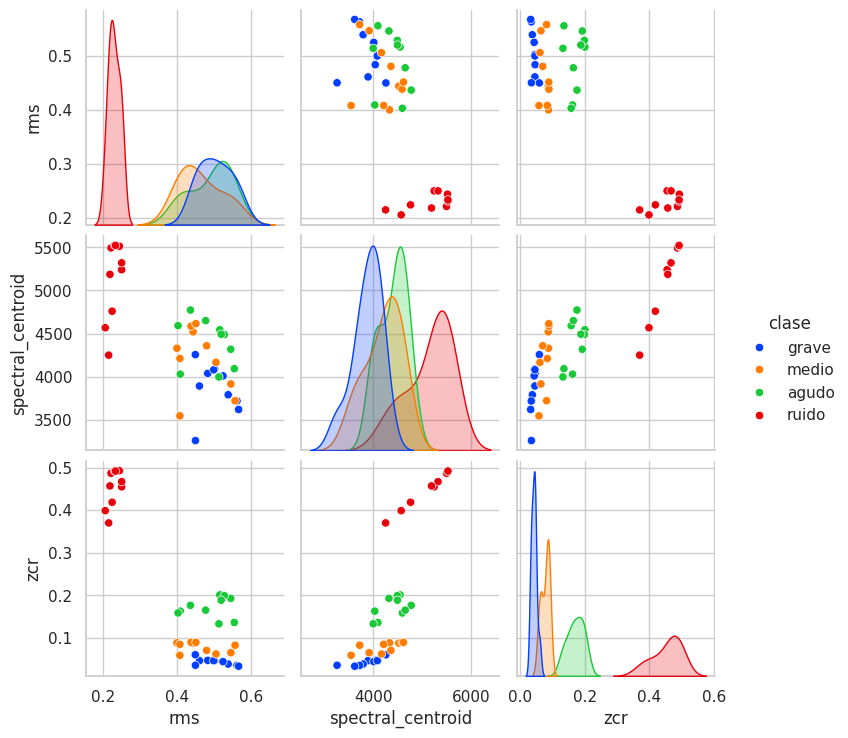

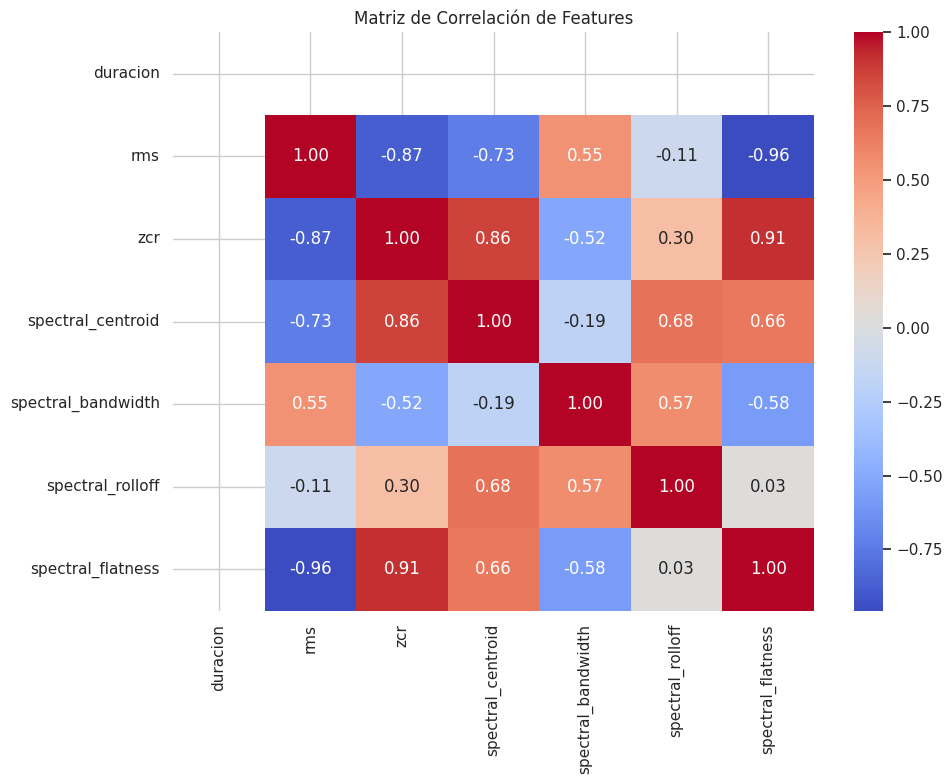


--- PARES CON ALTA CORRELACIÓN (|corr| > 0.7) ---
zcr                spectral_flatness    0.911450
spectral_centroid  zcr                  0.856922
                   rms                 -0.730222
rms                zcr                 -0.874452
                   spectral_flatness   -0.957614
dtype: float64

--- VARIANZA EXPLICADA ---
PC1: 0.6417
PC2: 0.2972
Total: 93.89%


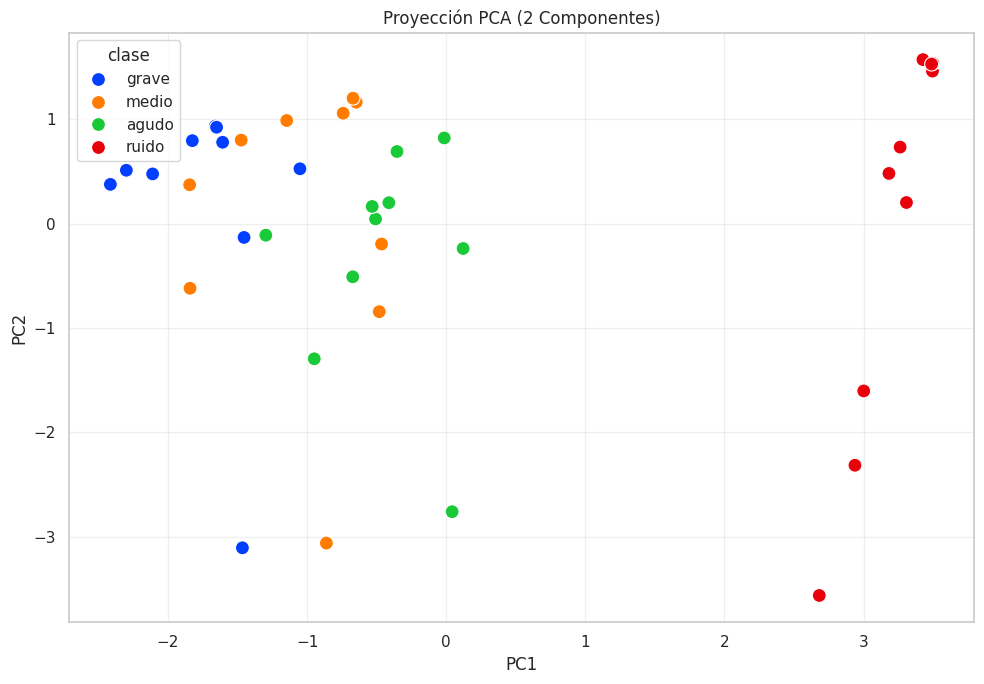

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")


# =========================================================
# a) Extracción de Features
# =========================================================
features_lista = []

for muestra in dataset_procesado:
    audio = muestra['audio']
    sr = muestra['sr']

    features = {
        'clase': muestra['clase'],
        'duracion': len(audio) / sr,
        'rms': np.sqrt(np.mean(audio**2)),
        'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
        'spectral_centroid': librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean(),
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean(),
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
        'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }

    features_lista.append(features)

df_features = pd.DataFrame(features_lista)

print("\n--- DATAFRAME DE FEATURES ---")
display(df_features.head())

# =========================================================
# b) Estadísticos descriptivos
# =========================================================
tabla_resumen = df_features.groupby('clase').agg(['mean', 'std', 'min', 'max']).round(3)

print("\n--- RESUMEN ESTADÍSTICO POR CLASE ---")
display(tabla_resumen)

# =========================================================
# c) Visualizaciones
# =========================================================

# -------- Boxplots --------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features_to_plot = ['rms', 'zcr', 'spectral_centroid', 'spectral_flatness']

for i, feat in enumerate(features_to_plot):
    sns.boxplot(x='clase', y=feat, data=df_features,
                ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribución de {feat}')

plt.tight_layout()
plt.show()
plt.close()

# -------- Pairplot --------
features_pair = ['rms', 'spectral_centroid', 'zcr', 'clase']

sns.pairplot(df_features[features_pair], hue='clase', palette='bright')
plt.show()
plt.close()

# -------- Heatmap de correlación --------
plt.figure(figsize=(10, 8))

df_numeric = df_features.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Features")

plt.tight_layout()
plt.show()
plt.close()

# =========================================================
# d) Análisis de correlación
# =========================================================
print("\n--- PARES CON ALTA CORRELACIÓN (|corr| > 0.7) ---")

altas_corr = corr_matrix.unstack().sort_values(ascending=False)
altas_corr = altas_corr[(abs(altas_corr) > 0.7) & (altas_corr != 1.0)]

print(altas_corr.drop_duplicates())

# =========================================================
# e) PCA
# =========================================================

# 1. Selección de features numéricas (quitamos duración si es constante)
X = df_numeric.drop(columns=['duracion'])

# 2. Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['clase'] = df_features['clase']

# 4. Varianza explicada
print("\n--- VARIANZA EXPLICADA ---")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# 5. Gráfico PCA
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='PC1', y='PC2',
    hue='clase',
    data=df_pca,
    palette='bright',
    s=100
)

plt.title("Proyección PCA (2 Componentes)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


## **Análisis de extracción de Features y EDA Estadístico**


**Análisis de las features**

A partir del análisis de las características extraídas, se observa que algunas features permiten diferenciar claramente las clases. En particular, el ZCR (Zero Crossing Rate) y la spectral flatness presentan valores significativamente mayores en la clase “ruido”, lo que indica una señal más aleatoria y menos estructurada.

Por otro lado, las clases “grave”, “medio” y “agudo” presentan valores más bajos de ZCR y flatness, lo que refleja una mayor periodicidad y estructura tonal en las señales.


**Análisis de correlación**

El análisis de correlación muestra la presencia de relaciones fuertes entre algunas variables. Por ejemplo, existe una alta correlación positiva entre ZCR y spectral flatness (0.91), lo que sugiere que ambas capturan información similar relacionada con la aleatoriedad de la señal.

Asimismo, se observa una correlación negativa entre RMS y spectral flatness (-0.95), indicando que señales más energéticas tienden a ser menos ruidosas.

Estas correlaciones evidencian la existencia de redundancia entre features, lo cual podría optimizarse en etapas posteriores mediante selección de variables.


**Análisis PCA**

El análisis de componentes principales permitió reducir la dimensionalidad del dataset conservando aproximadamente el 93.89% de la varianza total, lo que indica una representación eficiente de los datos en dos dimensiones.

En la proyección PCA, se observa que la clase “ruido” se separa claramente del resto, debido a sus características espectrales distintivas. Sin embargo, las clases “grave”, “medio” y “agudo” presentan cierto solapamiento, lo que sugiere que, si bien son parcialmente distinguibles, no están completamente separadas en el espacio de features actual.


**Conclusión sobre separabilidad**

En conjunto, los resultados indican que las features extraídas son adecuadas para caracterizar las señales y permiten una discriminación parcial entre clases.

La clase “ruido” es claramente diferenciable, mientras que las clases tonales presentan cierto grado de superposición. Esto sugiere que, si bien el conjunto de características es informativo, podría complementarse con nuevas features (por ejemplo, MFCC o características temporales adicionales) para mejorar la separabilidad en tareas de clasificación.